In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from functions import calc_metrics, plot_prediction_results
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [11]:
# split train and test data
def split_data(df, target_col='Adj_Close', train_ratio=0.8):
    df['Date'] = pd.to_datetime(df['Date'])
    df_sorted = df.sort_values(by='Date').reset_index(drop=True)
    split_idx = int(len(df_sorted) * train_ratio)
    train_data = df_sorted.iloc[:split_idx][target_col].reset_index(drop=True)
    test_data = df_sorted.iloc[split_idx:][target_col].reset_index(drop=True)
    test_dates = df_sorted.iloc[split_idx:]['Date'].reset_index(drop=True)
    return train_data, test_data, test_dates

# find optimal parameters
def find_best_arima(train_data):
    best_model = auto_arima(
        train_data,
        seasonal=False,
        test="adf",
        d=None,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False,
    )
    order = best_model.order
    print(f"[Auto ARIMA] Best order = {order}")
    return order

def predict_arima(train_data, test_data, order, test_dates, refit_interval=20, ticker=None):
    history = list(train_data)
    pred_results = []
    
    n = len(test_data)
    model_fit = None
    
    for i in range(n):
        if i % refit_interval == 0:
            model = ARIMA(history, order=order)
            model_fit = model.fit()
            
        yhat = model_fit.forecast(steps=1)[0]
        pred_results.append(yhat)
        history.append(test_data[i])
        
    actual_values = test_data.values if hasattr(test_data, "values") else test_data
    
    df_result = pd.DataFrame({
        "Ticker": ticker,
        "Date": test_dates,
        "ARIMA_Predicted_Close": pred_results,
        "Adj_Close": actual_values
    })
    
    return df_result

In [12]:
def calc_metrics(df, actual_col="Adj_Close", pred_col="ARIMA_Predicted_Close", ticker_col="Ticker"):
    df = df.copy()
    
    if ticker_col and ticker_col in df.columns and df[ticker_col].nunique() > 1:
        return df.groupby(ticker_col).apply(
            lambda x: calc_metrics(x, actual_col, pred_col, ticker_col=None)
        ).reset_index()
        
    df["Prev_Actual"] = df[actual_col].shift(1)
    df["Prev_Pred"] = df[pred_col].shift(1)
    df = df.dropna(subset=[actual_col, pred_col, "Prev_Actual", "Prev_Pred"])
    
    y_true = df[actual_col]
    y_pred = df[pred_col]
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))
    r2 = r2_score(y_true, y_pred)
    
    actual_dir = np.sign(y_true.values - df["Prev_Actual"].values)
    pred_dir = np.sign(y_pred.values - df["Prev_Pred"].values)
    da = np.mean(actual_dir == pred_dir)
    
    mask = actual_dir != 0
    tpa = np.mean(actual_dir[mask] == pred_dir[mask]) if np.any(mask) else np.nan
    
    actual_vol = y_true - y_true.mean()
    pred_vol = y_pred - y_pred.mean()
    v_rmse = np.sqrt(mean_squared_error(actual_vol, pred_vol))
    
    metrics = pd.Series({
        "MSE": mse, "MAE": mae, "MAPE": mape, 
        "RMSE": rmse, "R2": r2, "DA": da, 
        "TPA": tpa, "V-RMSE": v_rmse
    })
    
    res_df = pd.DataFrame([metrics])
    return res_df

def plot_prediction_results(df, save_dir="../reports/figures/ARIMA"):
    ticker = df['Ticker'].iloc[0]
    
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    plt.plot(df['Date'], df['Adj_Close'], label='Actual Close', color='#1f77b4', linewidth=2)
    plt.plot(df['Date'], df['ARIMA_Predicted_Close'], label='ARIMA Predicted', color='#d62728', linestyle='--', linewidth=1.5)
    
    plt.title(f"ARIMA predicted results: {ticker}", fontsize=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    save_path = os.path.join(save_dir, f"{ticker}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

In [13]:
data_path = "../data/raw/sp500_top10_stocks_raw.csv"
df = pd.read_csv(data_path)

tickers = df['Ticker'].unique()

AAPL
[Auto ARIMA] Best order = (1, 1, 1)

ARIMA predicted result and metrics for AAPL stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,AAPL,2022-11-18,148.230681,148.902206
1,AAPL,2022-11-21,148.230681,145.673965
2,AAPL,2022-11-22,148.230681,147.809708
3,AAPL,2022-11-23,148.230681,148.685669
4,AAPL,2022-11-25,148.230681,145.772385
...,...,...,...,...
806,AAPL,2026-02-09,258.081018,274.619995
807,AAPL,2026-02-10,258.081018,273.679993
808,AAPL,2026-02-11,258.081018,275.500000
809,AAPL,2026-02-12,258.081018,261.730011


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,81.944107,6.812222,0.033863,9.052298,0.94039,0.02716,0.024752,8.965181


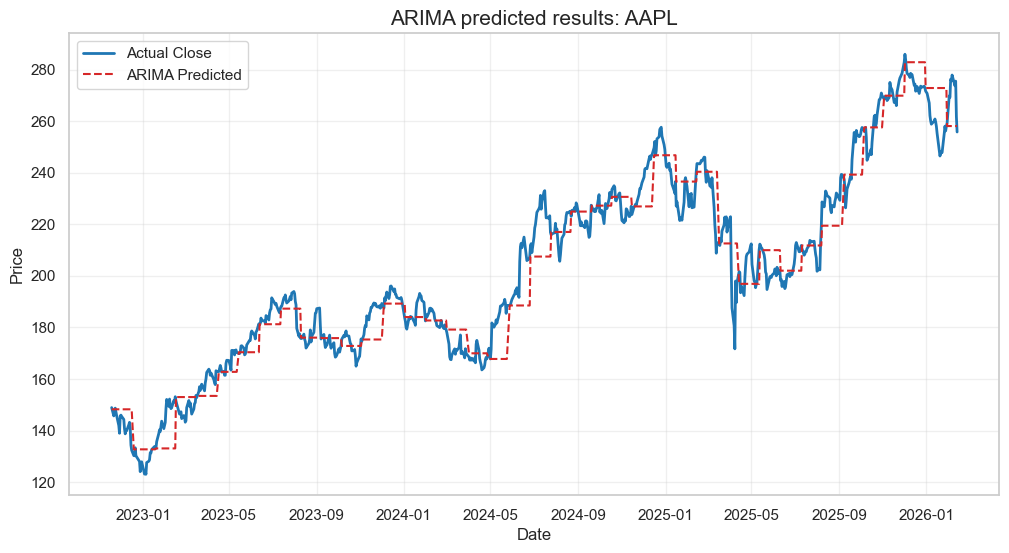

AMZN
[Auto ARIMA] Best order = (4, 1, 0)

ARIMA predicted result and metrics for AMZN stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,AMZN,2022-11-18,94.755575,94.139999
1,AMZN,2022-11-21,94.755575,92.459999
2,AMZN,2022-11-22,94.755575,93.199997
3,AMZN,2022-11-23,94.755575,94.129997
4,AMZN,2022-11-25,94.755575,93.410004
...,...,...,...,...
806,AMZN,2026-02-09,241.598453,208.720001
807,AMZN,2026-02-10,241.598453,206.960007
808,AMZN,2026-02-11,241.598453,204.080002
809,AMZN,2026-02-12,241.598453,199.600006


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,82.636172,6.528593,0.038226,9.090444,0.961586,0.034568,0.030979,9.079592


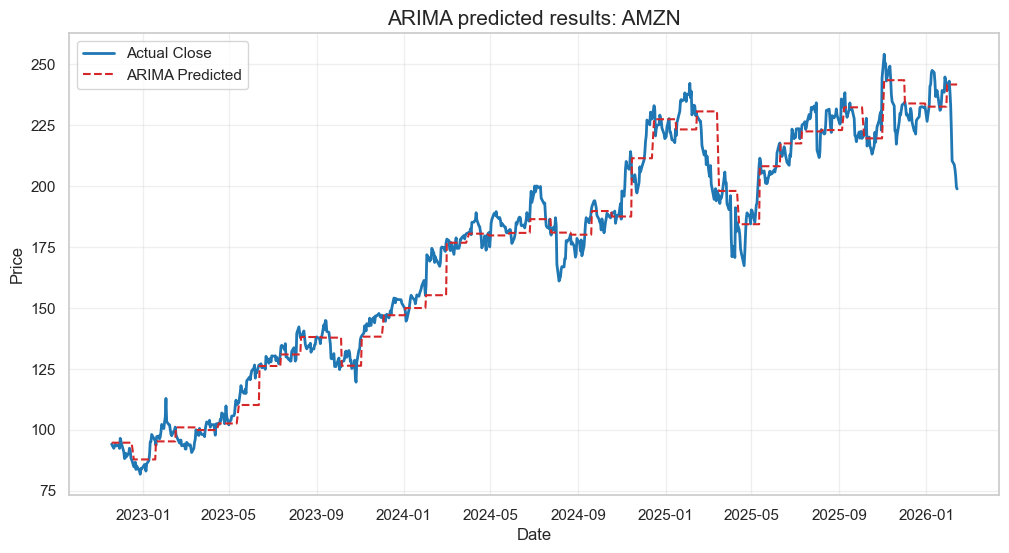

AVGO
[Auto ARIMA] Best order = (3, 1, 3)

ARIMA predicted result and metrics for AVGO stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,AVGO,2022-11-18,48.174941,48.847519
1,AVGO,2022-11-21,48.174941,49.063713
2,AVGO,2022-11-22,48.174941,50.259399
3,AVGO,2022-11-23,48.174941,50.599800
4,AVGO,2022-11-25,48.174941,50.246124
...,...,...,...,...
806,AVGO,2026-02-09,330.689278,343.940002
807,AVGO,2026-02-10,330.689278,340.440002
808,AVGO,2026-02-11,330.689278,342.760010
809,AVGO,2026-02-12,330.689278,331.170013


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,199.61346,9.338349,0.053792,14.128463,0.978738,0.028395,0.027194,14.007647


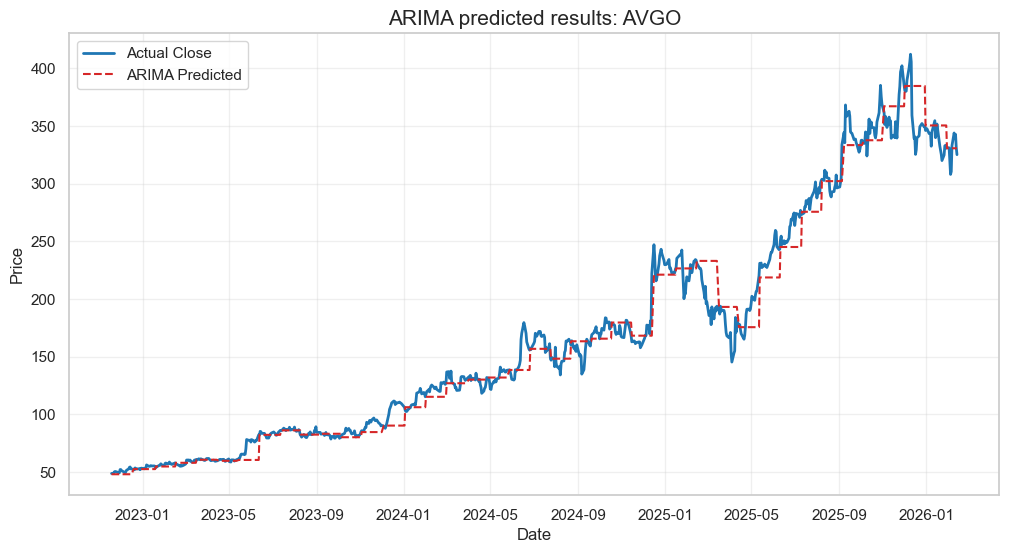

GOOG
[Auto ARIMA] Best order = (3, 1, 1)

ARIMA predicted result and metrics for GOOG stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,GOOG,2022-11-18,97.562895,97.071953
1,GOOG,2022-11-21,97.562895,95.116615
2,GOOG,2022-11-22,97.562895,96.605446
3,GOOG,2022-11-23,97.562895,98.084335
4,GOOG,2022-11-25,97.562895,96.873421
...,...,...,...,...
806,GOOG,2026-02-09,338.534752,324.399994
807,GOOG,2026-02-10,338.534752,318.630005
808,GOOG,2026-02-11,338.534752,311.329987
809,GOOG,2026-02-12,338.534752,309.369995


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,82.617708,6.553383,0.038817,9.089428,0.975994,0.028395,0.028395,8.792668


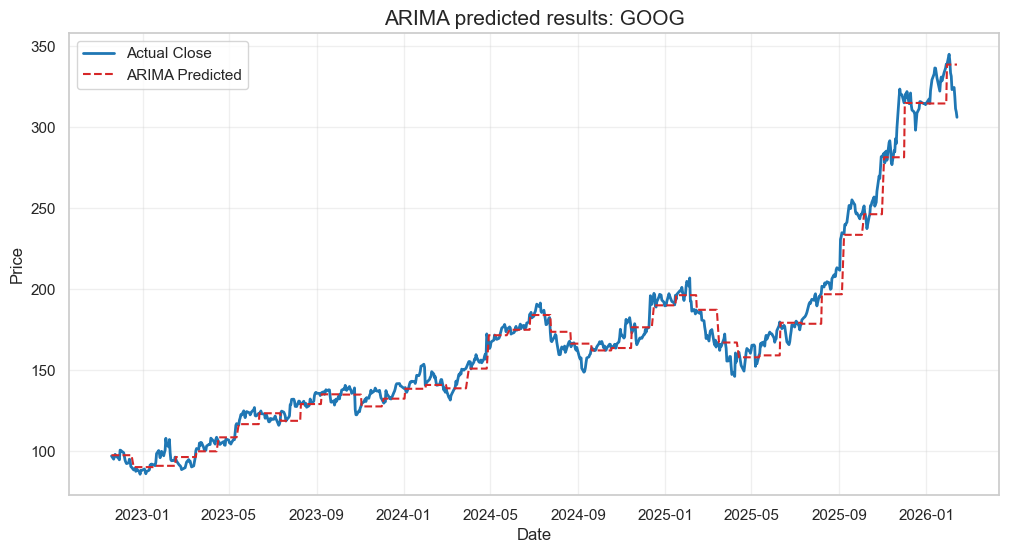

GOOGL
[Auto ARIMA] Best order = (1, 1, 3)

ARIMA predicted result and metrics for GOOGL stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,GOOGL,2022-11-18,97.434560,96.699364
1,GOOGL,2022-11-21,97.434560,94.883087
2,GOOGL,2022-11-22,97.434560,96.322227
3,GOOGL,2022-11-23,97.434560,97.721642
4,GOOGL,2022-11-25,97.434560,96.729141
...,...,...,...,...
806,GOOGL,2026-02-09,338.133465,324.320007
807,GOOGL,2026-02-10,338.133465,318.579987
808,GOOGL,2026-02-11,338.133465,310.959991
809,GOOGL,2026-02-12,338.133465,309.000000


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,83.098153,6.547891,0.038988,9.115819,0.975881,0.030864,0.028465,8.822532


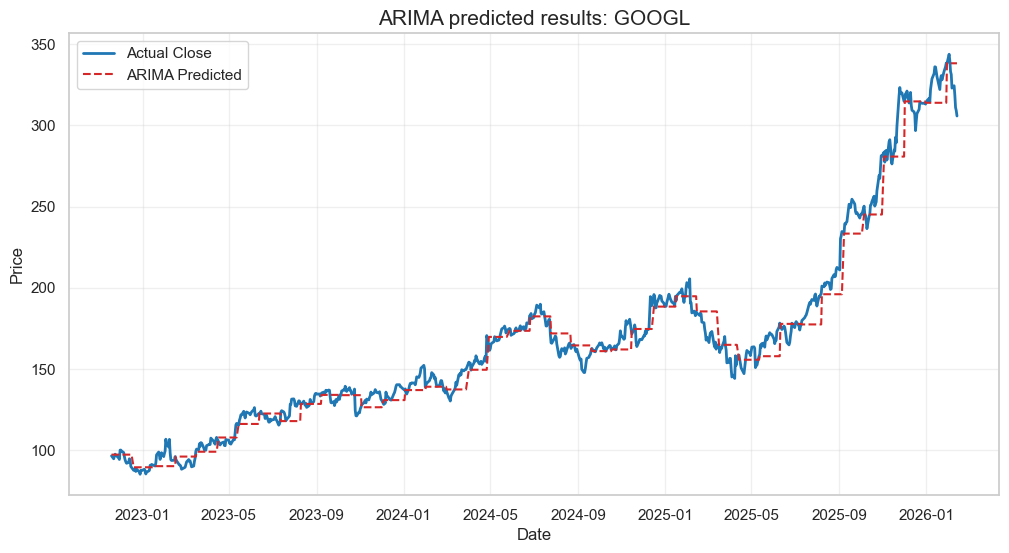

MSFT
[Auto ARIMA] Best order = (2, 1, 1)

ARIMA predicted result and metrics for MSFT stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,MSFT,2022-11-18,236.041840,235.587341
1,MSFT,2022-11-21,236.041840,236.397980
2,MSFT,2022-11-22,236.041840,239.308350
3,MSFT,2022-11-23,236.041840,241.798828
4,MSFT,2022-11-25,236.041840,241.710938
...,...,...,...,...
806,MSFT,2026-02-09,435.936923,413.600006
807,MSFT,2026-02-10,435.936923,413.269989
808,MSFT,2026-02-11,435.936923,404.369995
809,MSFT,2026-02-12,435.936923,401.839996


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,253.829146,12.567717,0.032989,15.932016,0.959397,0.032099,0.032099,15.873655


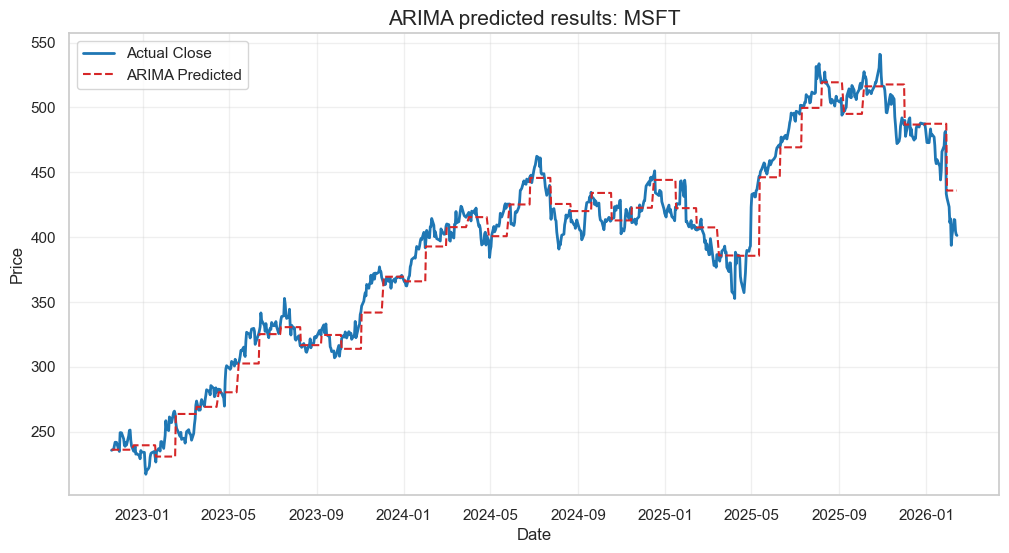

NVDA
[Auto ARIMA] Best order = (2, 1, 2)

ARIMA predicted result and metrics for NVDA stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,NVDA,2022-11-18,15.720163,15.389654
1,NVDA,2022-11-21,15.720163,15.297769
2,NVDA,2022-11-22,15.720163,16.017866
3,NVDA,2022-11-23,15.720163,16.498257
4,NVDA,2022-11-25,15.720163,16.249571
...,...,...,...,...
806,NVDA,2026-02-09,192.746050,190.039993
807,NVDA,2026-02-10,192.746050,188.539993
808,NVDA,2026-02-11,192.746050,190.050003
809,NVDA,2026-02-12,192.746050,186.940002


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,78.606157,6.45325,0.071894,8.866011,0.975486,0.02716,0.025958,8.740128


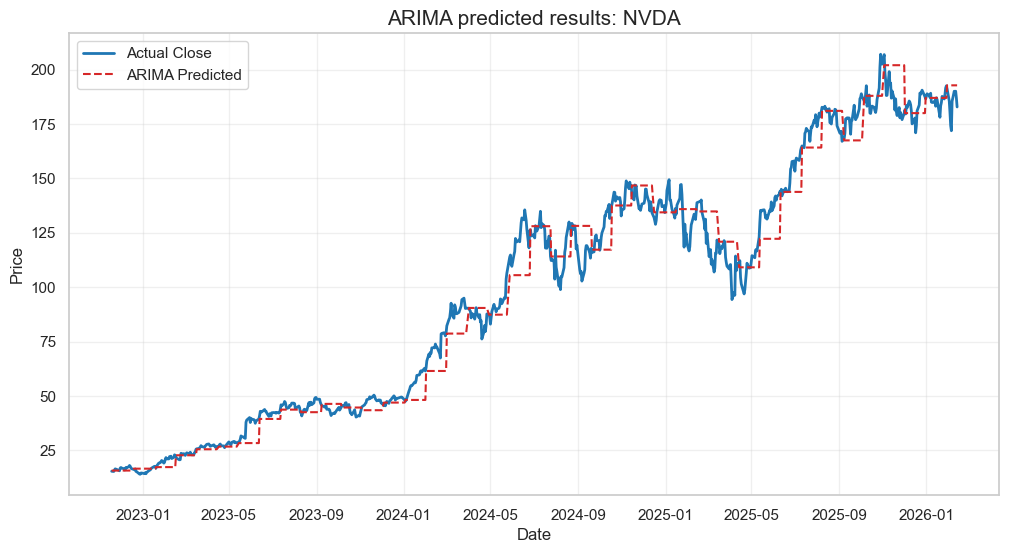

TSLA
[Auto ARIMA] Best order = (1, 1, 0)

ARIMA predicted result and metrics for TSLA stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,TSLA,2022-12-23,125.822485,123.150002
1,TSLA,2022-12-27,125.822485,109.099998
2,TSLA,2022-12-28,125.822485,112.709999
3,TSLA,2022-12-29,125.822485,121.820000
4,TSLA,2022-12-30,125.822485,123.180000
...,...,...,...,...
782,TSLA,2026-02-09,406.540693,417.320007
783,TSLA,2026-02-10,406.540693,425.209991
784,TSLA,2026-02-11,406.540693,428.269989
785,TSLA,2026-02-12,406.540693,417.070007


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,1284.317627,24.60179,0.092047,35.837378,0.85048,0.029262,0.029262,35.775842


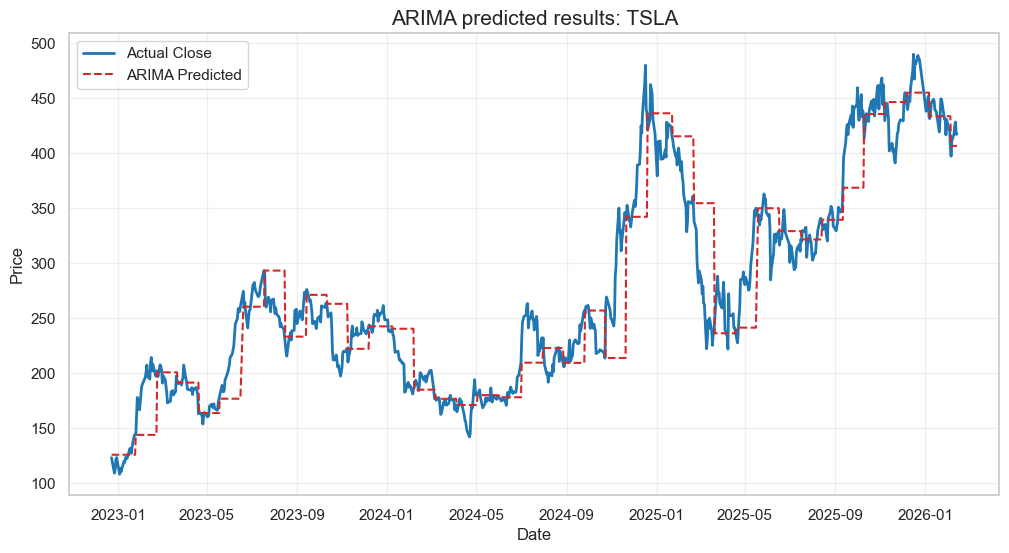

META
[Auto ARIMA] Best order = (1, 1, 3)

ARIMA predicted result and metrics for META stock price


,Ticker,Date,ARIMA_Predicted_Close,Adj_Close
0,META,2023-05-15,232.329141,237.203079
1,META,2023-05-16,232.329141,237.163330
2,META,2023-05-17,232.329141,240.807877
3,META,2023-05-18,232.329141,245.137650
4,META,2023-05-19,232.329141,243.936020
...,...,...,...,...
686,META,2026-02-09,734.349232,677.219971
687,META,2026-02-10,734.349232,670.719971
688,META,2026-02-11,734.349232,668.690002
689,META,2026-02-12,734.349232,649.809998


,MSE,MAE,MAPE,RMSE,R2,DA,TPA,V-RMSE
0,1199.164287,24.777496,0.04829,34.628952,0.947889,0.033333,0.030523,34.112329


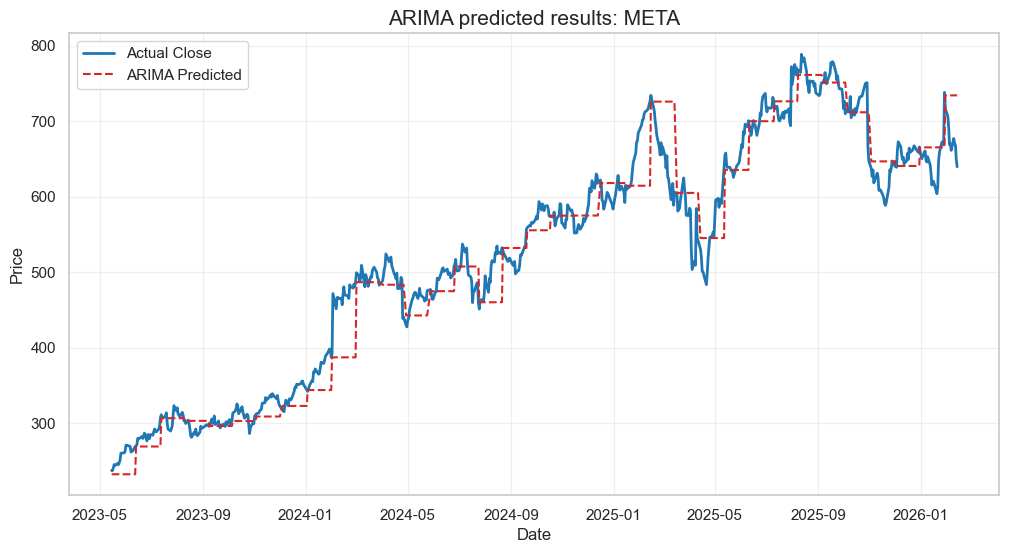

In [15]:
for ticker in tickers:
    print(ticker)
    ticker_df = df[df['Ticker']==ticker]
    train_data, test_data, test_dates = split_data(ticker_df)
    order = find_best_arima(train_data)
    result_ARIMA = predict_arima(train_data, test_data, order, test_dates, ticker=ticker)
    metrics_ARIMA = calc_metrics(result_ARIMA, actual_col="Adj_Close", pred_col="ARIMA_Predicted_Close", ticker_col="Ticker")
    metrics_ARIMA.to_csv(f'../reports/metrics/ARIMA/ARIMA_{ticker}_metrics.csv')
    print()
    print(f"ARIMA predicted result and metrics for {ticker} stock price")
    display(result_ARIMA)
    display(metrics_ARIMA)
    plot_prediction_results(result_ARIMA)
    print("==========================================")